<a href="https://colab.research.google.com/github/kailynforsythe/Opioid-Crisis/blob/main/EDA/notebooks/Capstone%20Project%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.cm as cm
import statsmodels.formula.api as smf
import seaborn as sns

In [10]:
print('Loading SUDORS-Fatal-Overdose-Data.csv...')
sudors = pd.read_csv("SUDORS-Fatal-Overdose-Data.csv")
display(sudors.head())

print('\nLoading naloxone_dispensing_rates.csv...')
naloxone = pd.read_csv("naloxone_dispensing_rates.csv")
display(naloxone.head())

print('\nLoading filtered_nsduh.csv...')
nsduh = pd.read_csv("filtered_nsduh.csv", low_memory=False)
display(nsduh.head())

print('\nLoading circumstance.csv...')
circumstance = pd.read_csv("circumstance.csv")
display(circumstance.head())

Loading SUDORS-Fatal-Overdose-Data.csv...


,Jurisdiction,year,alldrug_deaths,alldrug_rate,opioids_deaths,opioids_rate,imfs_deaths,imfs_rate,heroin_deaths,heroin_rate,...,rx_drugs_deaths,rx_drugs_percent,illegal_drugs_deaths,illegal_drugs_percent,counterfeit_pills_deaths,counterfeit_pills_percent,ever_SUDtrt_deaths,ever_SUDtrt_percent,rx_OUD_deaths,rx_OUD_percent
0,Alaska,2020,171,23.8,111,15.4,58,8.0,48,6.7,...,57,33.3,60,35.1,12,7.0,11,6.4,7,4.1
1,Arizona,2020,2412,34.0,1867,26.3,1474,20.8,288,4.1,...,773,32.2,940,39.1,422,17.6,270,11.2,58,2.4
2,Colorado,2020,1329,22.4,976,16.3,558,9.3,280,4.6,...,336,26.8,469,37.5,116,9.3,141,11.3,43,3.4
3,Connecticut,2020,1374,39.4,1278,36.7,1158,33.4,267,7.5,...,227,16.5,728,53.0,39,2.8,207,15.1,56,4.1
4,Delaware,2020,446,47.4,417,44.5,372,40.0,109,11.7,...,156,35.2,247,55.8,16,3.6,99,22.3,33,7.4



Loading naloxone_dispensing_rates.csv...


,Year,Location,STATE_ABBREV,STATE_FIPS,Naloxone Dispensing Rate,Naloxone Dispensing Rate (per 100 persons)
0,2019,Alabama,AL,1,0.2,0.2 - 0.4
1,2019,Alaska,AK,2,0.2,0.2 - 0.4
2,2019,Arizona,AZ,4,0.4,0.2 - 0.4
3,2019,Arkansas,AR,5,0.1,<0.2
4,2019,California,CA,6,0.5,0.4 - 0.5



Loading filtered_nsduh.csv...


,SERVICE,MILSTAT,NOMARR2,LVLDIFMEM2,LVLDIFCARE2,IRSEX,IREDUHIGHST2,SEXAGE,HEALTH2,EDUSCKMON,...,BOOKED,BKSRVIOL,BKSMASLT,BKPOSTOB,BKDRVINF,BKDRUG,PNRNMLAS1,OPINMMON,FUPNRNM18,OPINMYR
0,2,99,99,1,1,2,9,5,4.0,99,...,2,99,99,99,99,99,91,0.0,2.0,0.0
1,2,99,1,1,1,1,11,5,3.0,99,...,2,99,99,99,99,99,91,0.0,2.0,0.0
2,2,99,99,1,1,2,11,4,2.0,99,...,2,99,99,99,99,99,91,0.0,2.0,0.0
3,2,99,99,2,1,1,6,5,2.0,99,...,2,99,99,99,99,99,91,0.0,2.0,0.0
4,2,99,99,1,1,1,8,3,1.0,99,...,2,99,99,99,99,99,91,0.0,2.0,0.0



Loading circumstance.csv...


,Jurisdiction,opioids_rate,rx_drugs_percent,illegal_drugs_percent,counterfeit_pills_percent,homeless_percent,curr_paintrt_percent,ever_MHSUDtrt_percent,curr_MHSUDtrt_percent,hx_selfharm_percent,recentopioid_percent,priorod_mon_percent,intervopp_percent,curr_SUDtrt_percent,mhdiag_percent,bystander_percent,priorod_percent,recentrelease_percent
0,Alabama,23.200,5.80,30.200,1.800,7.70,0.80,8.30,3.90,1.300,1.300,2.100,40.800,2.000,8.70,28.00,5.80,4.800
1,Alaska,29.620,26.48,42.880,10.560,15.30,14.98,29.70,14.52,10.300,5.440,2.820,82.820,4.320,38.92,61.60,12.60,10.740
2,Arizona,27.000,27.68,35.340,17.360,22.20,9.56,22.34,12.92,12.860,5.260,2.160,74.460,5.720,32.40,53.10,11.08,12.000
3,Arkansas,11.375,27.40,35.725,6.275,6.40,6.70,8.65,1.65,1.875,1.975,2.175,52.375,0.875,15.10,36.05,6.30,6.275
4,Colorado,19.140,26.02,40.240,14.320,19.16,9.72,17.44,11.04,12.640,7.720,2.840,72.120,4.340,31.78,51.92,12.26,10.200


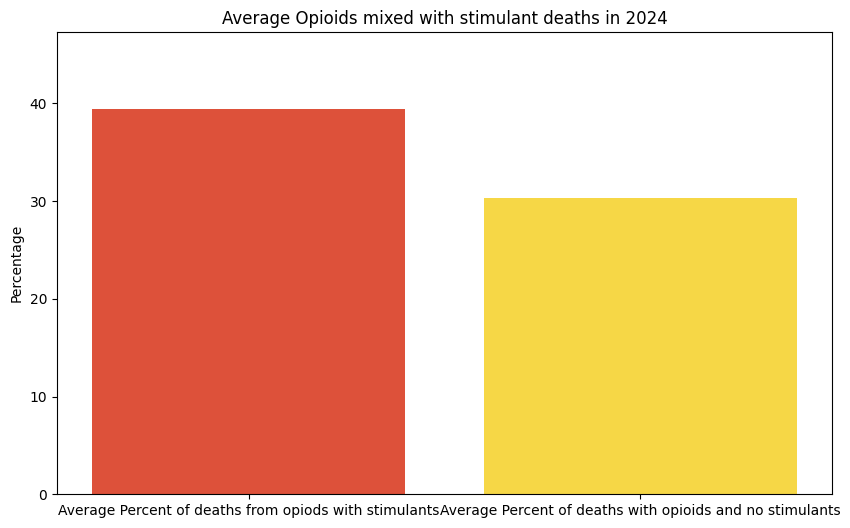

In [12]:
# Calculate average opioid percent and rx opioid percent
avg_opioids_stim_percent = sudors_2024['opioids_stim_percent'].mean()
avg_opioids_nostim_percent = sudors_2024['opioids_nostim_percent'].mean()

# Create a bar graph
labels = ['Average Percent of deaths from opiods with stimulants', 'Average Percent of deaths with opioids and no stimulants']
values = [avg_opioids_stim_percent, avg_opioids_nostim_percent]

# Get colors from the 'inferno' colormap, avoiding purple and orange
colors = cm.inferno(np.linspace(0.6, 0.9, len(labels)))

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=colors)
plt.ylabel('Percentage')
plt.title('Average Opioids mixed with stimulant deaths in 2024')
plt.ylim(0, max(values) * 1.2) # Set y-axis limit for better visualization
plt.savefig("Average Opioids mixed with stimulant deaths in 2024.png", bbox_inches="tight")
plt.show()

Opioid overdoses more often occur alongside a stimulant but its pretty close to the amount of deaths with no stimulant.

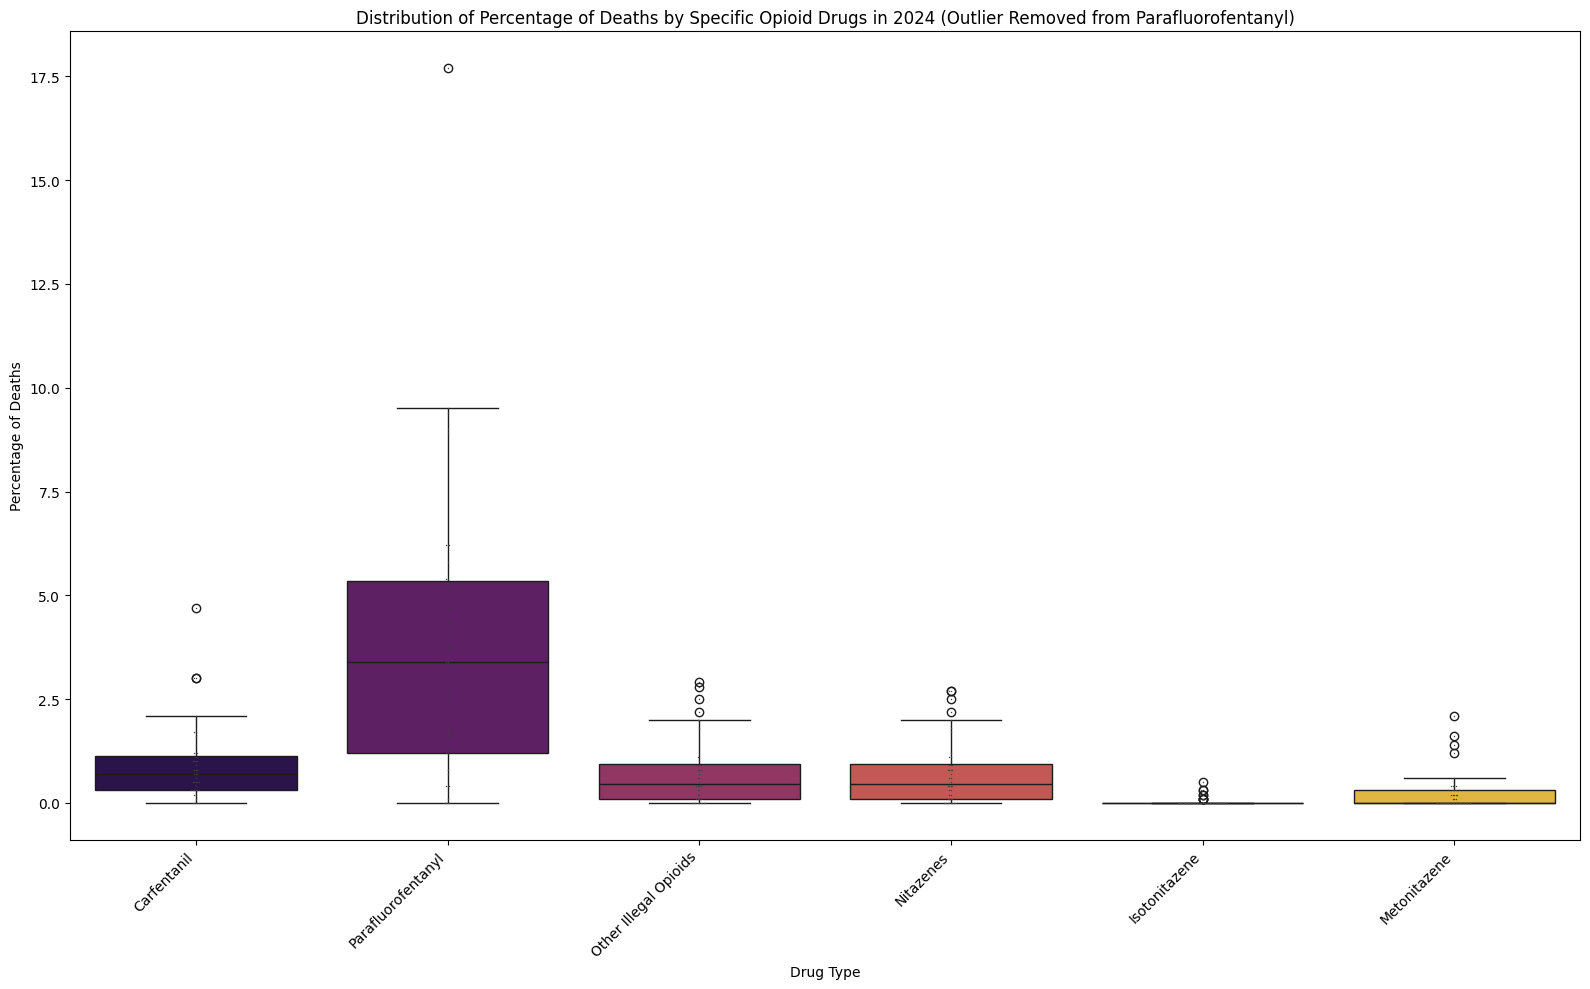

In [13]:
# Filter data for 2024
sudors_2024 = sudors[sudors['year'] == 2024]

# Define the percentage columns for the specified drugs
drug_percent_columns = [
    'carfentanil_percent',
    'parafluorofentanyl_percent',
    'other_illegal_opioids_percent',
    'nitazenes_percent',
    'isotonitazene_percent',
    'metonitazene_percent'
]

# Prepare data for plotting
labels_percents = [
    'Carfentanil',
    'Parafluorofentanyl',
    'Other Illegal Opioids',
    'Nitazenes',
    'Isotonitazene',
    'Metonitazene'
]

# Convert relevant columns to numeric, coercing errors to NaN and then filling NaN with 0
# Do not average across jurisdictions and year, keep individual data points
df_plot = sudors_2024[drug_percent_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# Melt the DataFrame to long format suitable for seaborn boxplot
df_melted = df_plot.melt(var_name='Drug Type', value_name='Percentage')

# Map the column names to more readable labels
label_map = dict(zip(drug_percent_columns, labels_percents))
df_melted['Drug Type'] = df_melted['Drug Type'].map(label_map)

# Identify and remove the outlier for 'Parafluorofentanyl'
parafluorofentanyl_data = df_melted[df_melted['Drug Type'] == 'Parafluorofentanyl']
max_parafluorofentanyl = parafluorofentanyl_data['Percentage'].max()

# Filter out the single maximum outlier from 'Parafluorofentanyl'
df_melted_filtered = df_melted[
    ~((df_melted['Drug Type'] == 'Parafluorofentanyl') & (df_melted['Percentage'] == max_parafluorofentanyl))
].copy()

plt.figure(figsize=(16, 10)) # Increased figure size for bigger boxes
# Create a boxplot to show the distribution
sns.boxplot(x='Drug Type', y='Percentage', data=df_melted_filtered, palette='inferno', hue='Drug Type', legend=False)

# Overlay a swarmplot to show individual data points
# Using color=".25" for a dark grey shade for the points and reduced size
sns.swarmplot(x='Drug Type', y='Percentage', data=df_melted_filtered, color=".25", size=1) # Reduced size to make them dots

plt.ylabel('Percentage of Deaths')
plt.title('Distribution of Percentage of Deaths by Specific Opioid Drugs in 2024 (Outlier Removed from Parafluorofentanyl)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Distribution of Percentage of Deaths by Specific Opioid Drugs in 2024_boxplot_outlier_removed.png", bbox_inches="tight")
plt.show()

Parafluorofentanyl accounts for the most opioid deaths. It is worth noting that most people don't know when they are consuming this drug. Parafluorofentanyl is adjacent to fentanyl and often laces other drugs to increase volume at a lower cost. There was an occurence of parafluorofentanyl at 25% far from any other points so I removed it to shorten the scale and make the boxes easier to see.

In [14]:
print(sudors.columns.tolist())

['Jurisdiction', 'year', 'alldrug_deaths', 'alldrug_rate', 'opioids_deaths', 'opioids_rate', 'imfs_deaths', 'imfs_rate', 'heroin_deaths', 'heroin_rate', 'rxopioids_deaths', 'rxopioids_rate', 'stimulant_deaths', 'stimulant_rate', 'cocaine_deaths', 'cocaine_rate', 'meth_deaths', 'meth_rate', 'nonopioid_sedatives_deaths', 'nonopioid_sedatives_rate', 'benzodiazepines_deaths', 'benzodiazepines_rate', 'opioids_percent', 'imfs_percent', 'heroin_percent', 'rxopioids_percent', 'stimulant_percent', 'cocaine_percent', 'meth_percent', 'nonopioid_sedatives_percent', 'benzodiazepines_percent', 'combo1_drugs', 'combo1_deaths', 'combo1_percent', 'combo2_drugs', 'combo2_deaths', 'combo2_percent', 'combo3_drugs', 'combo3_deaths', 'combo3_percent', 'combo4_drugs', 'combo4_deaths', 'combo4_percent', 'combo5_drugs', 'combo5_deaths', 'combo5_percent', 'opioids_stim_deaths', 'opioids_stim_percent', 'opioids_nostim_deaths', 'opioids_nostim_percent', 'stim_noopioids_deaths', 'stim_noopioids_percent', 'noopioid

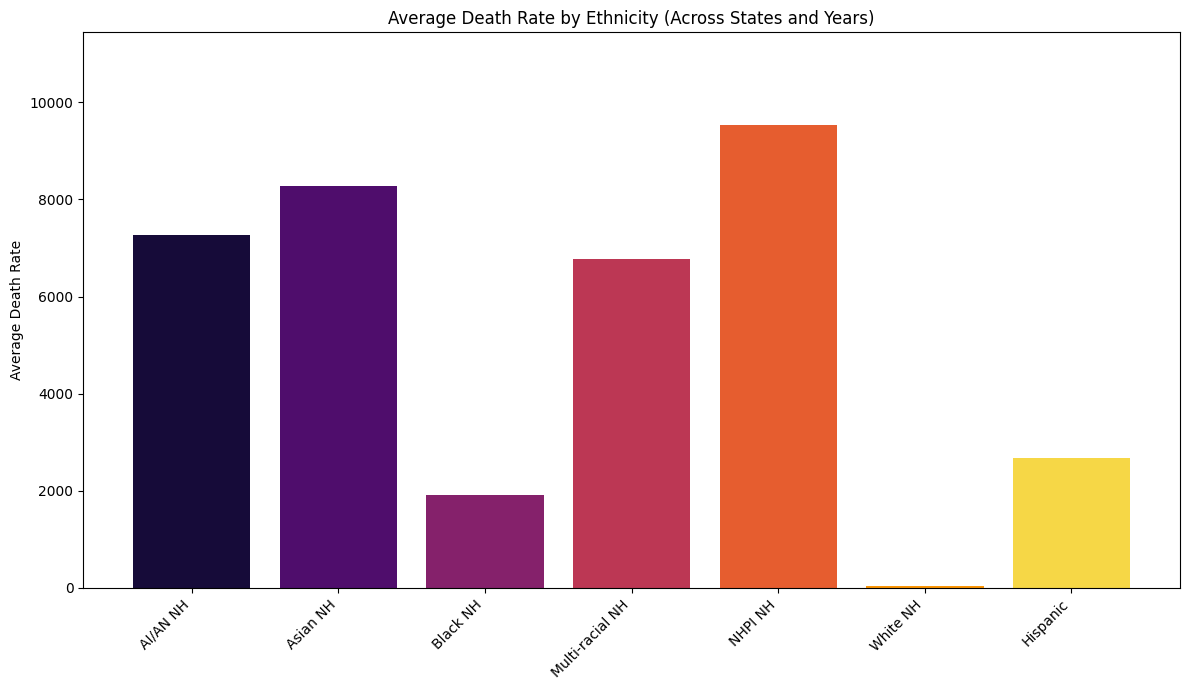

In [15]:
ethnicity_rate_columns = [
    'aian_nh_rate',
    'asian_nh_rate',
    'black_nh_rate',
    'multi_nh_rate',
    'nhpi_nh_rate',
    'white_nh_rate',
    'hisp_rate'
]

average_ethnicity_rates = sudors[ethnicity_rate_columns].mean()

# Prepare data for plotting
labels = ['AI/AN NH', 'Asian NH', 'Black NH', 'Multi-racial NH', 'NHPI NH', 'White NH', 'Hispanic']
values = average_ethnicity_rates.values

# Get colors from the 'inferno' colormap
colors = cm.inferno(np.linspace(0.1, 0.9, len(labels)))

plt.figure(figsize=(12, 7))
plt.bar(labels, values, color=colors)
plt.ylabel('Average Death Rate')
plt.title('Average Death Rate by Ethnicity (Across States and Years)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig("Average Death Rate by Ethnicity (Across States and Years).png", bbox_inches="tight")
plt.show()

Native hawaiian pacific islander has the highest overdose feath race next to asian.

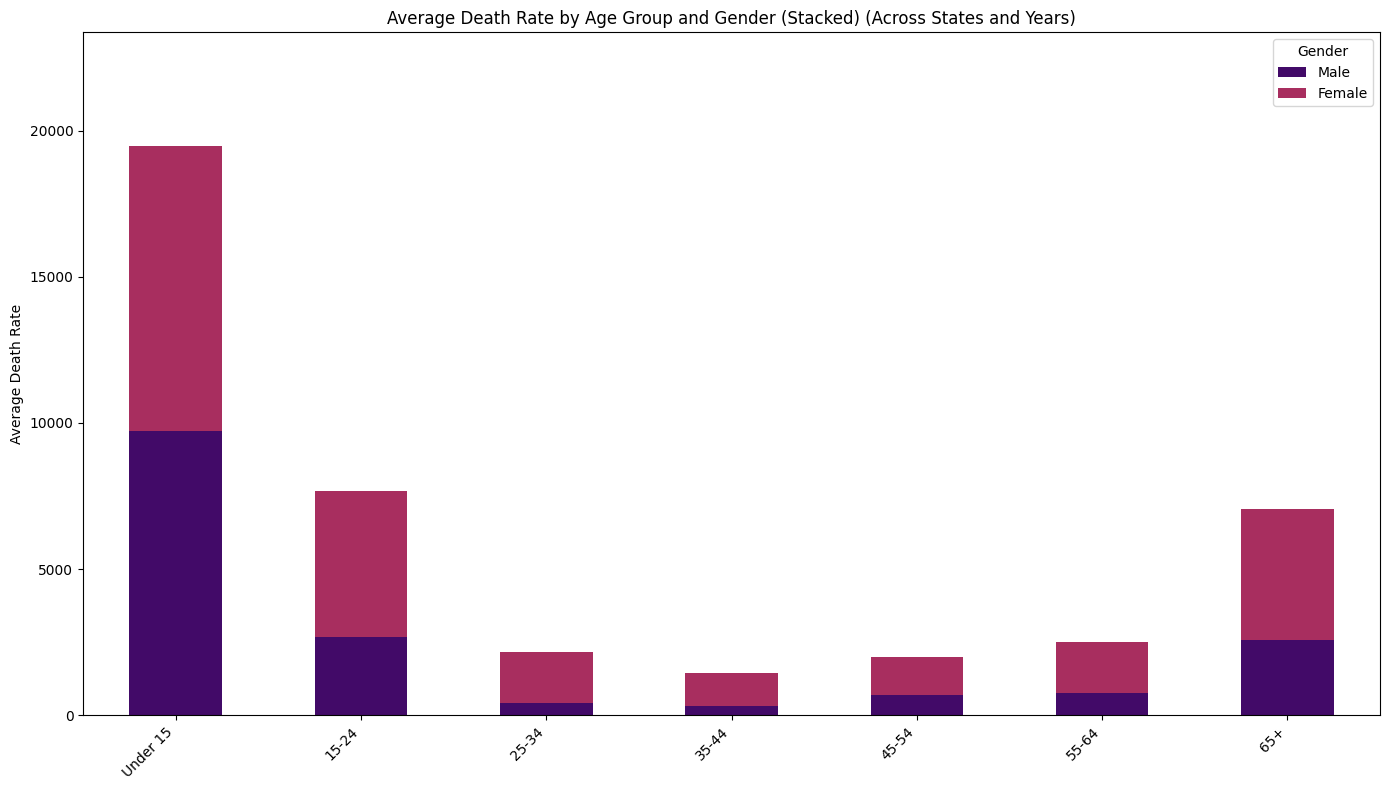

In [16]:
age_labels = [
    'Under 15',
    '15-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
]

# Male death rates by age group
male_age_rate_columns = [
    'male_under15_rate',
    'male_15_24_rate',
    'male_25_34_rate',
    'male_35_44_rate',
    'male_45_54_rate',
    'male_55_64_rate',
    'male_65plus_rate'
]
average_male_age_rates = sudors[male_age_rate_columns].mean().values

# Female death rates by age group
female_age_rate_columns = [
    'female_under15_rate',
    'female_15_24_rate',
    'female_25_34_rate',
    'female_35_44_rate',
    'female_45_54_rate',
    'female_55_64_rate',
    'female_65plus_rate'
]
average_female_age_rates = sudors[female_age_rate_columns].mean().values

# Combine male and female rates into a DataFrame for easier plotting
df_rates = pd.DataFrame({
    'Male': average_male_age_rates,
    'Female': average_female_age_rates
}, index=age_labels)

# Plotting a stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
df_rates.plot(kind='bar', stacked=True, color=[plt.cm.inferno(0.2), plt.cm.inferno(0.45)], ax=ax)

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Average Death Rate')
ax.set_title('Average Death Rate by Age Group and Gender (Stacked) (Across States and Years)')
ax.set_xticks(np.arange(len(age_labels)))
ax.set_xticklabels(age_labels, rotation=45, ha='right')
ax.legend(title='Gender')

# Set y-axis limit for better visualization
max_rate = df_rates.sum(axis=1).max()
ax.set_ylim(0, max_rate * 1.2)

fig.tight_layout()
plt.savefig("Average Death Rate by Age Group and Gender_Stacked.png", bbox_inches="tight")
plt.show()

Younger people tend to overdose more regardless of gender, there it decreases with age but begins to increase again around the late 50's.

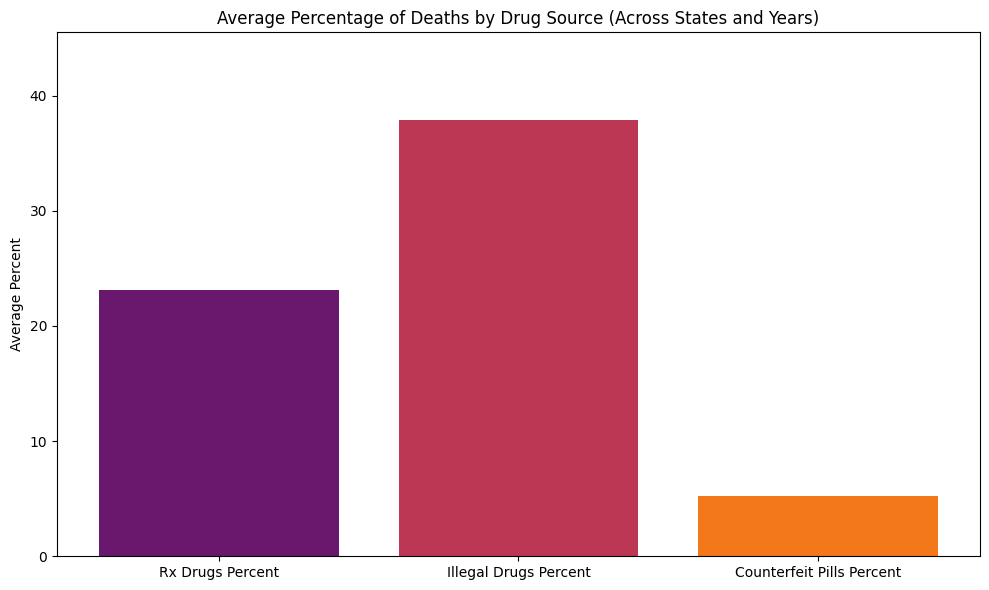

In [17]:
rx_percent = sudors['rx_drugs_percent'].mean()
illegal_percent = sudors['illegal_drugs_percent'].mean()
counterfeit_percent = sudors['counterfeit_pills_percent'].mean()

labels = ['Rx Drugs Percent', 'Illegal Drugs Percent', 'Counterfeit Pills Percent']
values = [rx_percent, illegal_percent, counterfeit_percent]

# Get colors from the 'inferno' colormap
colors = cm.inferno(np.linspace(0.3, 0.7, len(labels)))

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=colors)
plt.ylabel('Average Percent')
plt.title('Average Percentage of Deaths by Drug Source (Across States and Years)')
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig("Average Percentage of Deaths by Drug Source.png", bbox_inches="tight")
plt.show()

Most overdoses are from illegal drugs, there is a significant rx overdoses too.

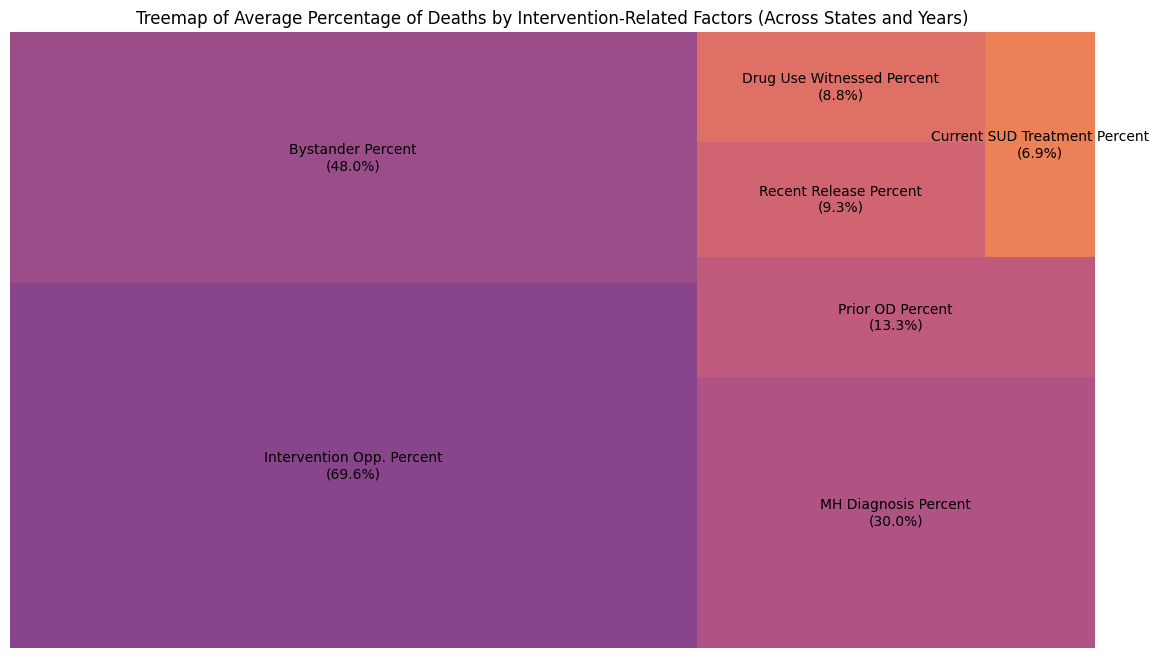

In [18]:
!pip install squarify
import squarify # Import squarify for treemap visualization

intervention_columns = [
    'intervopp_percent',
    'curr_SUDtrt_percent',
    'drugusewitnessed_percent',
    'mhdiag_percent',
    'bystander_percent',
    'priorod_percent',
    'recentrelease_percent'
]

average_intervention_percents = sudors[intervention_columns].mean()

labels = [
    'Intervention Opp. Percent',
    'Current SUD Treatment Percent',
    'Drug Use Witnessed Percent',
    'MH Diagnosis Percent',
    'Bystander Percent',
    'Prior OD Percent',
    'Recent Release Percent'
]
values = average_intervention_percents.values

# Sort values and labels to get a more organized treemap
sorted_indices = np.argsort(values)[::-1]
values = values[sorted_indices]
labels = [labels[i] for i in sorted_indices]

# Get colors from the 'inferno' colormap
colors = [cm.inferno(0.3 + 0.4 * (i / len(labels))) for i in range(len(labels))]

plt.figure(figsize=(14, 8))
squarify.plot(sizes=values, label=[f'{l}\n({v:.1f}%)' for l, v in zip(labels, values)], color=colors, alpha=.8)
plt.title('Treemap of Average Percentage of Deaths by Intervention-Related Factors (Across States and Years)')
plt.axis('off') # Hide axes for a cleaner treemap
plt.savefig("Treemap of Average Percentage of Deaths by Intervention-Related Factors.png", bbox_inches="tight")
plt.show()

The most prevention opportunities were the presence of a bystander and an opportunity for prevention. Majority of people who overdosed had an intervention opportunity that evidently did not work so I would like to provide suggestions from research on effective interventions

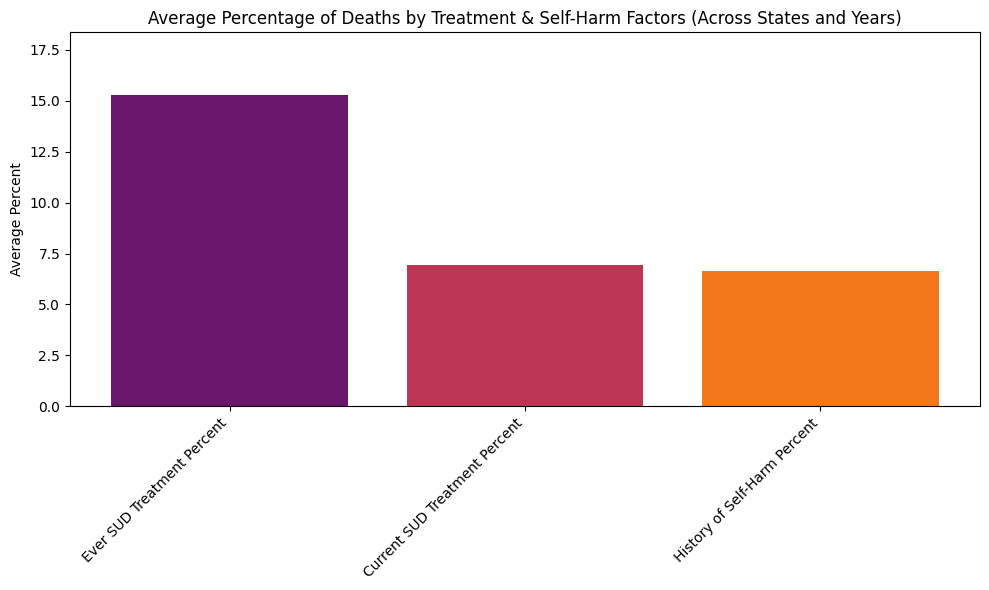

In [19]:
treatment_selfharm_columns = [
    'ever_SUDtrt_percent',
    'curr_SUDtrt_percent',
    'hx_selfharm_percent'
]

average_treatment_selfharm_percents = sudors[treatment_selfharm_columns].mean()

labels = [
    'Ever SUD Treatment Percent',
    'Current SUD Treatment Percent',
    'History of Self-Harm Percent'
]
values = average_treatment_selfharm_percents.values

# Get colors from the 'inferno' colormap
colors = cm.inferno(np.linspace(0.3, 0.7, len(labels)))

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=colors)
plt.ylabel('Average Percent')
plt.title('Average Percentage of Deaths by Treatment & Self-Harm Factors (Across States and Years)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig("Average Percentage of Deaths by Treatment & Self-Harm Factors.png", bbox_inches="tight")
plt.show()

15% of people who overdose have been in substance use disorder treatment. I would also like to provide suggestions for reform.

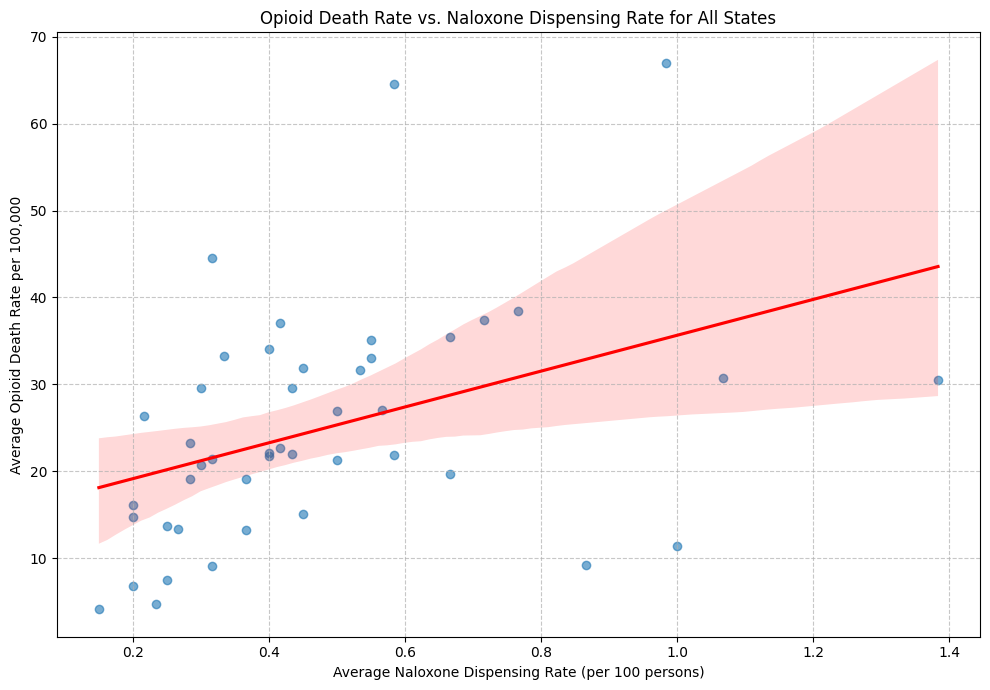

In [20]:

# Calculate the average opioid death rate per state from the SUDORS data
average_opioid_rate_by_state = sudors.groupby('Jurisdiction')['opioids_rate'].mean().reset_index()

# Calculate the average Naloxone Dispensing Rate per state from the naloxone data
average_naloxone_rate_by_state = naloxone.groupby('Location')['Naloxone Dispensing Rate'].mean().reset_index()

# Merge the opioid states data with the average naloxone dispensing rates
merged_data = pd.merge(average_opioid_rate_by_state, average_naloxone_rate_by_state, left_on='Jurisdiction', right_on='Location', how='inner')

# Drop the duplicate 'Location' column as 'Jurisdiction' is sufficient
merged_data = merged_data.drop(columns='Location')

# Prepare data for plotting
opioid_rates = merged_data['opioids_rate']
naloxone_rates = merged_data['Naloxone Dispensing Rate']

plt.figure(figsize=(10, 7))
sns.regplot(x=naloxone_rates, y=opioid_rates, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

# Add labels and title
plt.xlabel('Average Naloxone Dispensing Rate (per 100 persons)')
plt.ylabel('Average Opioid Death Rate per 100,000')
plt.title('Opioid Death Rate vs. Naloxone Dispensing Rate for All States')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Opioid Death Rate vs Naloxone Dispensing Rate Scatter Plot_All States.png", bbox_inches="tight")
plt.show()

There is a slight trend but it's minimal. Efforts to dispense Naloxone are either ineffective in finding the right people, or does not prevent significant amounts of overdoses.